# Zarr multiscale pyramids — fast previews

When a raster is big enough that an interactive map widget shouldn't pull the full array
for every pan, the right move is to **store decimated overviews alongside the full-resolution
data** and serve the lowest-resolution level that still resolves the viewport.

pyramids writes those overviews into the same Zarr store via `overview_factors=[…]` and
tags them with an OGC / OME-Zarr `multiscales` block so GDAL's Zarr driver also recognises
them. Reading any level back is a single call:

```python
Dataset.from_zarr(store, level=8)   # 1/8 resolution preview
```

This notebook builds a 256 × 512 synthetic raster, writes it with four overview levels,
and shows the bytes-on-disk cost vs the bytes-read win for a thumbnail-style preview.

## Setup

In [1]:
import os
os.environ["MPLBACKEND"] = "Agg"
%matplotlib inline

import tempfile
from pathlib import Path

import numpy as np

from pyramids.dataset import Dataset

workspace = Path(tempfile.mkdtemp(prefix="pyramids-zarr-pyramid-"))
print("workspace:", workspace)

ROWS, COLS = 256, 512

# A radial gradient gives the resampler something realistic to chew on (sharp edges average
# differently from smooth bands), so the overview levels don't look like flat copies.
yy, xx = np.mgrid[0:ROWS, 0:COLS].astype(np.float32)
rad = np.hypot(yy - ROWS / 2, xx - COLS / 2).astype(np.float32)
arr = np.stack([rad, rad / rad.max() * 100.0]).astype(np.float32)

mem = Dataset.create_from_array(
    arr,
    top_left_corner=(0.0, float(ROWS)),
    cell_size=1.0,
    epsg=4326,
    no_data_value=-9999.0,
)
mem.band_names = ["distance_m", "distance_pct"]

source_tif = workspace / "source.tif"
mem.to_file(source_tif)
ds = Dataset.read_file(source_tif)
ds.band_names = ["distance_m", "distance_pct"]
print("shape    :", ds.shape)
print("cell_size:", ds.cell_size)

2026-05-28 23:23:42 | INFO | pyramids.base.config | Logging is configured.


workspace: C:\Users\main\AppData\Local\Temp\pyramids-zarr-pyramid-2mzuum84
shape    : (2, 256, 512)
cell_size: 1.0


## 1. Write the store with four overview levels

`overview_factors=[2, 4, 8, 16]` emits decimated arrays `data_2`, `data_4`, `data_8`,
`data_16` alongside the full-resolution `data`, plus an OGC `multiscales` attribute on the
root group that maps each level to its scale factor.

In [2]:
import zarr
from zarr.codecs import BloscCodec

store = workspace / "pyramid.zarr"
ds.to_zarr(
    store,
    overview_factors=[2, 4, 8, 16],
    overview_resampling="average",
    compressor=BloscCodec(cname="zstd", clevel=5),
)

g = zarr.open_group(str(store), mode="r")
print("arrays    :", sorted(g.array_keys()))
for entry in g.attrs["multiscales"][0]["datasets"]:
    scale = entry["coordinateTransformations"][0]["scale"]
    print(f"  {entry['path']:<8} scale={scale}")


arrays    : ['data', 'data_16', 'data_2', 'data_4', 'data_8', 'spatial_ref', 'x', 'y']
  data     scale=[1.0, 1.0, 1.0]
  data_2   scale=[1.0, 2.0, 2.0]
  data_4   scale=[1.0, 4.0, 4.0]
  data_8   scale=[1.0, 8.0, 8.0]
  data_16  scale=[1.0, 16.0, 16.0]


## 2. Read a preview

`level=` is the decimation factor (`1` = full resolution, `2`/`4`/… = the matching
overview). The cell size scales by the factor, so the geobox stays consistent — a preview
of the same AOI just has fewer pixels.

In [3]:
for level in (1, 2, 4, 8, 16):
    lvl = Dataset.from_zarr(store, level=level)
    print(f"level={level:>2}  shape={lvl.shape!s:<18}  cell_size={lvl.cell_size:>5}  "
          f"bytes={lvl.read_array().nbytes:>9}")

level= 1  shape=(2, 256, 512)       cell_size=  1.0  bytes=  1048576
level= 2  shape=(2, 128, 256)       cell_size=  2.0  bytes=   262144
level= 4  shape=(2, 64, 128)        cell_size=  4.0  bytes=    65536
level= 8  shape=(2, 32, 64)         cell_size=  8.0  bytes=    16384
level=16  shape=(2, 16, 32)         cell_size= 16.0  bytes=     4096


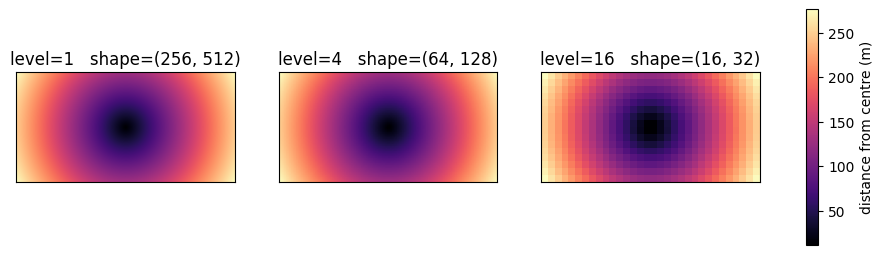

In [4]:
# --- Visualise the pyramid ---
# Same scene at full resolution and at two decimated levels. The full-res panel shows
# the radial gradient with its native pixel grain; the level-4 panel is one quarter of
# the pixels per side (the average resampler smooths out high-frequency detail); the
# level-16 panel is the 1/16 thumbnail, perfect for a map-widget overview where each
# tile is only a few dozen pixels tall. Crucially, the geobox is preserved — all three
# panels cover the *same* spatial extent, just sampled coarser.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, lvl in zip(axes, (1, 4, 16)):
    arr_lvl = Dataset.from_zarr(store, level=lvl).read_array()[0]
    im = ax.imshow(arr_lvl, cmap="magma")
    ax.set_title(f"level={lvl}   shape={arr_lvl.shape}")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.85, label="distance from centre (m)")


## 3. Storage cost vs preview win

Storing four overview levels adds bytes to the store. The break-even question: how does
the full pyramid's on-disk footprint compare to a flat (no-overviews) store, and how much
smaller is a preview read than a full-resolution read?

In [5]:
def store_size(p: Path) -> int:
    return sum(f.stat().st_size for f in p.rglob("*") if f.is_file())

flat = workspace / "flat.zarr"
ds.to_zarr(flat, compressor=BloscCodec(cname="zstd", clevel=5))

flat_bytes      = store_size(flat)
pyramid_bytes   = store_size(store)
level1_payload  = Dataset.from_zarr(store, level=1 ).read_array().nbytes
level16_payload = Dataset.from_zarr(store, level=16).read_array().nbytes

print(f"flat store    : {flat_bytes:>8} bytes")
print(f"pyramid store : {pyramid_bytes:>8} bytes  ({pyramid_bytes/flat_bytes:.2f}x flat)")
print(f"full read     : {level1_payload:>8} bytes")
print(f"preview read  : {level16_payload:>8} bytes  ({level1_payload/level16_payload:.1f}x smaller)")

flat store    :   586104 bytes
pyramid store :   877675 bytes  (1.50x flat)
full read     :  1048576 bytes
preview read  :     4096 bytes  (256.0x smaller)


## Where to next

- Single-raster zarr basics: [`zarr-basics.ipynb`](zarr-basics.ipynb).
- Cube workflow with append / region writes: [`zarr-cube.ipynb`](zarr-cube.ipynb).
- Reading non-pyramids GeoZarr stores: [`zarr-foreign-geozarr.ipynb`](zarr-foreign-geozarr.ipynb).
- Full API + on-disk layout: [Zarr reference](../../reference/zarr.md).